In [1]:
import numpy as np
import os
import random
import platform
from PIL import Image, ImageDraw, ImageFont
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [3]:
# ==========================================
# 2. PYTHON SCRIPT
# ==========================================

# --- CONFIGURATION ---
IMAGE_SIZE = 64
SAMPLES_PER_CHAR = 1000
FILENAME = "dataset_aligned.npz"
OUTPUT_PATH = FILENAME
PADDING = 10          # MATCHES YOUR SPLITTING SCRIPT

In [6]:
# Character set
chars_lower = "abcdefghijklmnopqrstuvwxyz"
chars_upper = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
numbers = "0123456789"
punctuation = ".,:!?()'"

ALL_CHARS = list(chars_lower + chars_upper + numbers + punctuation)

FONT_DIR = os.path.join(os.getcwd(), "fonts")

def get_fonts():
    """Lädt alle TTF-Fonts aus dem Projektordner."""
    if not os.path.exists(FONT_DIR):
        print(f"FEHLER: Font-Ordner nicht gefunden: {FONT_DIR}")
        return []
    return [
        os.path.join(FONT_DIR, f)
        for f in os.listdir(FONT_DIR)
        if f.lower().endswith(".ttf")
    ]


def generate_and_save():
    # 1. Locate fonts
    valid_fonts = get_fonts()
    print(f"\nFonts found: {len(valid_fonts)}")

    if not valid_fonts:
        print("CRITICAL ERROR: No fonts found. Please install fonts or check paths.")
        return

    total_images = len(ALL_CHARS) * SAMPLES_PER_CHAR
    print(f"Generating {total_images} images (Target: {OUTPUT_PATH})...")

    # 2. Allocate Memory
    X = np.empty((total_images, IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
    y = np.empty(total_images, dtype=np.int32)

    current_idx = 0

    # Calculate the target "Line Height" to match OpenCV script
    # In OpenCV: size(64) - padding(18)*2 = 28 pixels available for the line.
    target_line_height = IMAGE_SIZE - (PADDING * 2)

    # 3. Generation Loop
    pbar = tqdm(total=total_images, desc="Progress")

    for char_idx, char in enumerate(ALL_CHARS):
        for _ in range(SAMPLES_PER_CHAR):
            font_path = random.choice(valid_fonts)

            # ---------------------------------------------------------
            # KEY CHANGE 1: Font Size matches "Line Height"
            # ---------------------------------------------------------
            # We don't scale randomly. We scale to fill the 'line strip'.
            # A font size of X pixels usually results in a line height slightly larger than X.
            # We use a factor (e.g. 0.9 to 1.0) to simulate slight zoom variations in scanning.
            font_size = int(target_line_height * random.uniform(0.90, 1.05))

            # Small random shift to simulate scanning misalignment
            offset_x = random.randint(-2, 2)
            offset_y = random.randint(-2, 2)

            try:
                font = ImageFont.truetype(font_path, font_size)
            except:
                continue

            # Create Canvas (1-bit, White background)
            img = Image.new('1', (IMAGE_SIZE, IMAGE_SIZE), color=1)
            draw = ImageDraw.Draw(img)

            # ---------------------------------------------------------
            # KEY CHANGE 2: Horizontal Center, Vertical Anchor
            # ---------------------------------------------------------

            # A. Horizontal Centering (Standard)
            # We still center the character horizontally (Left-to-Right)
            length = draw.textlength(char, font=font)
            pos_x = (IMAGE_SIZE - length) / 2

            # B. Vertical Alignment (Baseline Preservation)
            # instead of centering the *ink* (bbox), we place the *font line* # at the padding line.
            # The OpenCV script centers the line strip in the 64px canvas.
            # This means the top of the line strip is at Y = PADDING (18).
            pos_y = PADDING

            # Apply offsets
            pos_x += offset_x
            pos_y += offset_y

            # Draw text using anchor="la" (Left Ascender)
            # "la" means (pos_x, pos_y) is the Top-Left of the Ascender line.
            # This forces the text to hang correctly from the PADDING line.
            # Note: If this fails on old Pillow versions, update Pillow.
            draw.text((pos_x, pos_y), char, font=font, fill=0, anchor="la")

            # Convert to numpy array (0=Black, 255=White)
            img_array = np.array(img, dtype=np.uint8) * 255

            X[current_idx] = img_array
            y[current_idx] = char_idx
            current_idx += 1
            pbar.update(1)

    pbar.close()

    # 4. Save to Drive
    print(f"Saving to: {OUTPUT_PATH}...")
    chars = np.array(ALL_CHARS)

    try:
        np.savez_compressed(OUTPUT_PATH, X=X, y=y, chars=chars)
        print(f"SUCCESS! File saved: {OUTPUT_PATH}")
    except Exception as e:
        print(f"Error saving: {e}")

if __name__ == "__main__":
    generate_and_save()


Fonts found: 16
Generating 70000 images (Target: dataset_aligned.npz)...


Progress:   0%|          | 0/70000 [00:00<?, ?it/s]

Saving to: dataset_aligned.npz...
SUCCESS! File saved: dataset_aligned.npz


In [13]:
DATA_PATH = FILENAME

# Where to save the model checkpoints
CHECKPOINT_DIR = 'checkpoint4'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 20
TEST_SPLIT = 0.2  # 20% for testing

In [8]:
# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================
print(f"\nLoading data from {DATA_PATH}...")

try:
    data = np.load(DATA_PATH, allow_pickle=True)
    X = data['X']
    y = data['y']
    chars = data['chars']
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: File not found at {DATA_PATH}. Please check the path.")
    raise

# Normalize images: Convert 0-255 to 0.0-1.0 (Crucial for Neural Networks)
print("Normalizing images...")
X = X.astype('float32') / 255.0

# Reshape: Add the 'Channel' dimension.
# TensorFlow expects (Batch, Height, Width, Channels) -> (N, 128, 128, 1)
# If your images are grayscale, channels = 1.
if len(X.shape) == 3:
    X = np.expand_dims(X, axis=-1)

print(f"Input Shape: {X.shape}")

# One-Hot Encoding for Labels
num_classes = len(chars)
print(f"Number of classes: {num_classes}")
y = keras.utils.to_categorical(y, num_classes)

# Split into Train and Test sets
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")



Loading data from dataset_aligned.npz...
Data loaded successfully.
Normalizing images...
Input Shape: (70000, 64, 64, 1)
Number of classes: 70
Splitting data...
Training samples: 56000
Testing samples: 14000


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 70)             │        17,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 782,790 (2.99 MB)

 Trainable params: 782,790 (2.99 MB)

 Non-trainable params: 0 (0.00 B)


Starting training (64px input)...
Epoch 1/20
870/875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6082 - loss: 1.5547
Epoch 1: saving model to checkpoint4/model_epoch_01_val_acc_0.99.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.6098 - loss: 1.5479 - val_accuracy: 0.9869 - val_loss: 0.0331
Epoch 2/20
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9787 - loss: 0.0572
Epoch 2: saving model to checkpoint4/model_epoch_02_val_acc_0.98.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9787 - loss: 0.0572 - val_accuracy: 0.9849 - val_loss: 0.0310
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9828 - loss: 0.0417
Epoch 3: saving model to checkpoint4/model_epoch_03_val_acc_0.99.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9828 - loss: 0.0417 - val_accuracy: 0.9886 - val_loss: 0.0231
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9849 - loss: 0.0363
Epoch 4: saving model to checkpoint4/model_epoc

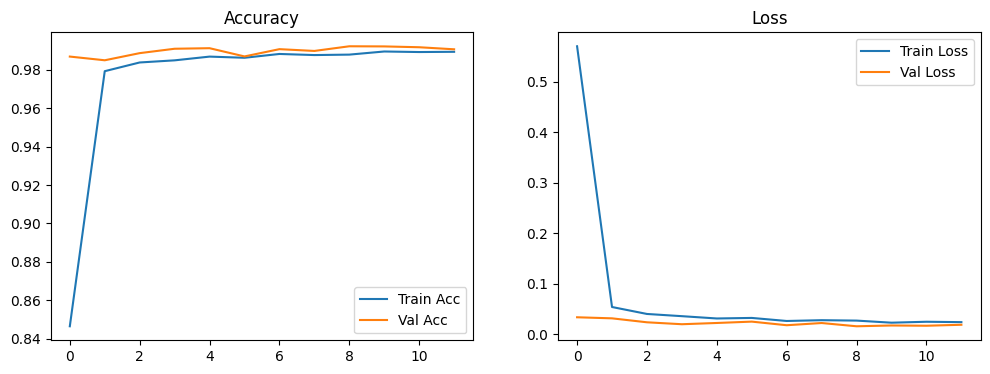

In [14]:

# ==========================================
# MODEL DEFINITION (64x64 INPUT)
# ==========================================
from tensorflow.keras import layers, models

model = models.Sequential([
    # --- Block 1 ---
    # Input: 32x32x1
    # Wir brauchen den Bias wieder (use_bias=True ist Standard), da kein BN da ist.
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),      # Output: 16x16

    # --- Block 2 ---
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),      # Output: 8x8

    # --- Block 3 ---
    # Hier gehen wir auf 128 Filter.
    # Nach diesem Pooling sind wir bei 4x4 Pixeln.
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),      # Output: 4x4

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # --- Classification Head ---
    layers.Flatten(),
    # Rechen-Check: 4 * 4 * 128 = 2.048 Parameter.
    # Das ist eine gesunde Größe für 32px Bilder.

    layers.Dropout(0.5), # Wichtig gegen Overfitting, besonders ohne BN

    layers.Dense(256, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 4. CALLBACKS (SAVING & LOGGING)
# ==========================================

# Ensure checkpoint dir exists
if not os.path.exists(CHECKPOINT_DIR):
    os.makedirs(CHECKPOINT_DIR)

# Checkpoint: Save model
checkpoint_path = os.path.join(CHECKPOINT_DIR, "model_epoch_{epoch:02d}_val_acc_{val_accuracy:.2f}.keras")

checkpoint_callback = callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=False,
    verbose=1
)

# Early Stopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ==========================================
# 5. TRAINING
# ==========================================
print("\nStarting training (64px input)...")

# Note: With smaller images (64px), you can often increase BATCH_SIZE
# (e.g., to 64 or 128) to speed up training if your RAM allows.
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback, early_stopping]
)

# ==========================================
# 6. EVALUATION & SAVING FINAL MODEL
# ==========================================
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Save the final model explicitly
final_save_path = os.path.join(CHECKPOINT_DIR, 'final_german_ocr_model_64px.keras')
model.save(final_save_path)
print(f"Final model saved to: {final_save_path}")

# Plot History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()